In [1]:
import os 
import time 
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy.special import j0
import plotly.graph_objects as go
from iminuit.cost import LeastSquares
from scipy.integrate import fixed_quad

In [2]:
save_folder = 'run7'
n_points = 10000

lower_factor = 0.99
upper_factor = 2 - lower_factor

In [3]:
# Load experimental data
atlas_data = pd.read_csv('../../../data/ens_atlas_difc0_2.dat', delim_whitespace=True, header=None)
totem_data = pd.read_csv('../../../data/ens_totem_difc0_2.dat', delim_whitespace=True, header=None)

# Function to process data for each experiment
def process_data(data, energy_blocks):
    x_values = []
    y_values = []
    y_errors = []
    
    for start, end in energy_blocks:
        block = data.iloc[start:end] if end is not None else data.iloc[start:]
        x_values.append(block[0].values)
        y_values.append(block[1].values)
        y_errors.append(block[2].values)
    
    return x_values, y_values, y_errors

# Energy ranges for each experiment (7TeV, 8TeV, 13TeV)
atlas_blocks = [(0, 29), (29, 58), (58, None)]
totem_blocks = [(0, 65), (65, 118), (118, None)]

# Process data
x_atlas, y_atlas, yerr_atlas = process_data(atlas_data, atlas_blocks)
x_totem, y_totem, yerr_totem = process_data(totem_data, totem_blocks)

# Extract values by energy (index 0=7TeV, 1=8TeV, 2=13TeV)
x_7_atlas, y_7_atlas, yerr_7_atlas = x_atlas[0], y_atlas[0], yerr_atlas[0]
x_8_atlas, y_8_atlas, yerr_8_atlas = x_atlas[1], y_atlas[1], yerr_atlas[1]
x_13_atlas, y_13_atlas, yerr_13_atlas = x_atlas[2], y_atlas[2], yerr_atlas[2]

x_7_totem, y_7_totem, yerr_7_totem = x_totem[0], y_totem[0], yerr_totem[0]
x_8_totem, y_8_totem, yerr_8_totem = x_totem[1], y_totem[1], yerr_totem[1]
x_13_totem, y_13_totem, yerr_13_totem = x_totem[2], y_totem[2], yerr_totem[2]

/tmp/ipykernel_9569/1301712433.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  atlas_data = pd.read_csv('../../../data/ens_atlas_difc0_2.dat', delim_whitespace=True, header=None)
/tmp/ipykernel_9569/1301712433.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  totem_data = pd.read_csv('../../../data/ens_totem_difc0_2.dat', delim_whitespace=True, header=None)


In [4]:

b_0 = (33 - 6) / (12 * np.pi)
Lambda = 0.284  # ΛQCD in GeV
gamma_1 = 0.084
gamma_2 = 2.36
rho = 4.0
s0 = 1.0
alpha_prime = 0.25



ensemble_parameters = {
    'atlas': {
        'log': {
            'epsilon': 0.0753,
            'mg': 0.356,
            'a1': 1.373,
            'a2': 2.50
        },
        'pl': {
            'epsilon': 0.0753,
            'mg': 0.421,
            'a1': 1.517,
            'a2': 2.05
        }
    },
    'totem': {
        'log': {
            'epsilon': 0.0892,
            'mg': 0.380,
            'a1': 1.491,
            'a2': 2.77
        },
        'pl':{
            'epsilon': 0.0892,
            'mg': 0.447,
            'a1': 1.689,
            'a2': 1.7
        }
    }
}

ensemble_atlas = 'atlas'  
ensemble_totem = 'totem'

log_model_type = 'log'
pl_model_type = 'pl'   

def get_parameters_with_variations(ensemble_parameters, ensemble_name, model_type, lower_factor=lower_factor, upper_factor=upper_factor):
    # Obtém os parâmetros iniciais
    initial_params = ensemble_parameters[ensemble_name][model_type]
    
    # Cria as variações
    initial_params_low = {k: v * lower_factor for k, v in initial_params.items()}
    initial_params_high = {k: v * upper_factor for k, v in initial_params.items()}
    
    return initial_params, initial_params_low, initial_params_high

# Get parameters for selected configuration
initial_params_log_atlas = ensemble_parameters[ensemble_atlas][log_model_type]
initial_params_pl_atlas = ensemble_parameters[ensemble_atlas][pl_model_type]

# Para Atlas
initial_params_log_atlas, initial_params_low_log_atlas, initial_params_high_log_atlas = \
    get_parameters_with_variations(ensemble_parameters, ensemble_atlas, log_model_type)

initial_params_pl_atlas, initial_params_low_pl_atlas, initial_params_high_pl_atlas = \
    get_parameters_with_variations(ensemble_parameters, ensemble_atlas, pl_model_type)

# Para Totem
initial_params_log_totem, initial_params_low_log_totem, initial_params_high_log_totem = \
    get_parameters_with_variations(ensemble_parameters, ensemble_totem, log_model_type)

initial_params_pl_totem, initial_params_low_pl_totem, initial_params_high_pl_totem = \
    get_parameters_with_variations(ensemble_parameters, ensemble_totem, pl_model_type)



In [5]:
def m2_log(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return mg ** 2 * ratio ** (-1 - gamma_1)

def m2_pl(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return (mg ** 4 / (q2 + mg ** 2)) * ratio ** (gamma_2 - 1)


def G_p(q2, a1, a2):
    return np.exp(-(a1 * q2 + a2 * q2 ** 2))

def alpha_D(q2, mg, m2_func):
    m2 = m2_func(q2, mg)
    return 1.0 / (b_0 * (q2 + m2) * np.log((q2 + 4 * m2) / (Lambda ** 2)))

def T_1(k, q, phi, mg, a1, a2, m2_func):
    q2 = q 
    qk_cos = np.sqrt(q) * k * np.cos(phi)
    qk_plus_squared = q2 / 4 + qk_cos + k ** 2
    qk_minus_squared = q2 / 4 - qk_cos + k ** 2
    alpha_D_plus = alpha_D(qk_plus_squared, mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)
    G0 = G_p(q2, a1, a2)
    return alpha_D_plus * alpha_D_minus * G0 ** 2

def T_2(k, q, phi, mg, a1, a2, m2_func):
    q2 = q 
    qk_cos = np.sqrt(q) * k * np.cos(phi)
    qk_plus_squared = q2 / 4 + qk_cos + k ** 2
    qk_minus_squared = q2 / 4 - qk_cos + k ** 2
    alpha_D_plus = alpha_D(qk_plus_squared, mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)
    factor = q2 + 9 * abs(k ** 2 - q2 / 4)
    G0 = G_p(q2, a1, a2)
    G_minus = G_p(factor, a1, a2)
    return alpha_D_plus * alpha_D_minus * G_minus * (2 * G0 - G_minus)

def integrand(y, x, mg, a1, a2, m2_func, q_val, sqrt_s):
    k = sqrt_s * x 
    phi = 2 * np.pi * y
    jacobian = 2 * np.pi * sqrt_s 
    return k * (T_1(k, q_val, phi, mg, a1, a2, m2_func) - T_2(k, q_val, phi, mg, a1, a2, m2_func)) * jacobian 

def sigma_tot(amp_value, s):
    return amp_value.imag / s * 0.389379323

def amp_calculation(diff_T, s, epsilon, t):
    alpha_pomeron = 1.0 + epsilon + alpha_prime * t
    regge_factor = (s**alpha_pomeron) * 1/(s0**(alpha_pomeron-1))
    return 1j * 8 * regge_factor * diff_T  

def differential_sigma(amp_value, s):
    amp_squared = amp_value.imag * amp_value.imag
    denominator = (16 * np.pi * s**2)
    return amp_squared / denominator * 0.389379323


In [6]:
def model_function(x, eps, mg, a1, a2, sqrt_s, model_type='log'):

    # Definindo os parâmetros específicos do modelo
    params = {
        'epsilon': eps,
        'mg': mg,
        'a1': a1,
        'a2': a2
    }
    
    # Escolhendo a massa conforme o modelo
    m2 = m2_log if model_type == 'log' else m2_pl
    
    dif_sigma_lst = []
    
    for q2 in x:
        t = -q2
        
        def inner_integral(x_inner):
            return fixed_quad(
                lambda y: integrand(y, x_inner, params['mg'], params['a1'], 
                                  params['a2'], m2, q2, sqrt_s),
                0, 1,
                n=n_points
            )[0]

        integral_value = fixed_quad(
            inner_integral,
            0, 1,
            n=n_points
        )[0]

        diff_T = integral_value
        s = sqrt_s ** 2
        amp_value = amp_calculation(diff_T, s, params['epsilon'], t)
        dif_sigma_value = differential_sigma(amp_value, s)
        dif_sigma_lst.append(dif_sigma_value)
    
    return np.array(dif_sigma_lst)

In [7]:
def create_least_squares(x, y, yerr, sqrt_s, model_type):
    return LeastSquares(x, y, yerr, 
        lambda x, eps, mg, a1, a2: model_function(x, eps, mg, a1, a2, sqrt_s, model_type))

def total_cost(dataset, model_type):
    return sum([
        create_least_squares(*dataset[7000], 7000, model_type),
        create_least_squares(*dataset[8000], 8000, model_type),
        create_least_squares(*dataset[13000], 13000, model_type)
    ])

# Estrutura dos dados por experimento
atlas_data = {
    7000: (x_7_atlas, y_7_atlas, yerr_7_atlas),
    8000: (x_8_atlas, y_8_atlas, yerr_8_atlas),
    13000: (x_13_atlas, y_13_atlas, yerr_13_atlas)
}

totem_data = {
    7000: (x_7_totem, y_7_totem, yerr_7_totem),
    8000: (x_8_totem, y_8_totem, yerr_8_totem),
    13000: (x_13_totem, y_13_totem, yerr_13_totem)
}

# Custos totais
total_cost_log_atlas = total_cost(atlas_data, 'log')
total_cost_pl_atlas = total_cost(atlas_data, 'pl')
total_cost_log_totem = total_cost(totem_data, 'log')
total_cost_pl_totem = total_cost(totem_data, 'pl')


In [8]:
# def otimization(total_cost_func, initial_params, initial_params_low, initial_params_high, model_type: str, ensemble: str):
#     print('\n')
#     print(80 * '-')
#     print(f"Iniciando otimização dos parâmetros usando LeastSquares para {model_type} em {ensemble.upper()}")

#     start_time = time.time()
    
#     m = Minuit(total_cost_func, 
#                eps=initial_params['epsilon'],
#                mg=initial_params['mg'],
#                a1=initial_params['a1'],
#                a2=initial_params['a2'])

#     if model_type == 'pl':
#         # Configurações adicionais
#         down = 0.97
#         up = 2- down

#         m.limits['mg'] = (down * initial_params['mg'], up *initial_params['mg'])
#         m.limits['eps'] = (down * initial_params['epsilon'], up *initial_params['epsilon'])
#         # m.limits['a2'] = (initial_params_low['a2'], initial_params_high['a2'])

#         m.limits['a1'] = (initial_params_low['a1'], initial_params_high['a1'])

#         # Configurações adicionais
#         m.strategy = 2
#         m.errordef = 7.79
#         m.tol = 1e-2
        
#         m.migrad(ncall=250)
#         m.hesse(ncall=20)

#     else:
#         down = 0.99
#         up = 2- down

#         m.limits['mg'] = (down * initial_params['mg'], up * initial_params['mg'])
#         m.limits['eps'] = (down * initial_params['epsilon'], up * initial_params['epsilon'])
#         m.limits['a2'] = (down * initial_params['a2'], up * initial_params['a2'])
#         # m.limits['a1'] = (down * initial_params['a1'], up * initial_params['a1'])

#         # Configurações adicionais
#         m.strategy = 2
#         m.errordef = 7.79
#         m.tol = 1e-2
         
#         m.migrad(ncall=85)
#         m.hesse(ncall=10)
            

#     print(f'Finalizado a minimização para {model_type} em {ensemble}')

#     execution_time = time.time() - start_time
    
#     minutes = int(execution_time // 60)
#     seconds = execution_time % 60
#     print(f'Tempo de execução para {model_type} em {ensemble}: {minutes} min {seconds:.2f} s \n')
    
#     print(f"Parâmetros otimizados para {model_type} em {ensemble}: \n")
#     print(f'mg: {m.values["mg"]} ± {m.errors["mg"]}')
#     print(f'eps: {m.values["eps"]} ± {m.errors["eps"]}')
#     print(f'a1: {m.values["a1"]} ± {m.errors["a1"]}')
#     print(f'a2: {m.values["a2"]} ± {m.errors["a2"]}')
#     print(f'chi2/ndof: {m.fval / m.ndof}')


#     return m




In [9]:
def otimization(total_cost_func, initial_params, initial_params_low, initial_params_high, model_type: str, ensemble: str):
    print('\n')
    print(80 * '-')
    print(f"Iniciando otimização dos parâmetros usando LeastSquares para {model_type} em {ensemble.upper()}")

    start_time = time.time()
    
    m = Minuit(total_cost_func, 
               eps=initial_params['epsilon'],
               mg=initial_params['mg'],
               a1=initial_params['a1'],
               a2=initial_params['a2'])

    if model_type == 'pl':
        # Configurações adicionais
        down = 0.91
        up = 2- down

        # m.limits['mg'] = (down * initial_params['mg'], up *initial_params['mg'])
        # m.limits['eps'] = (down * initial_params['epsilon'], up *initial_params['epsilon'])
        # # m.limits['a2'] = (initial_params_low['a2'], initial_params_high['a2'])

        m.limits['a1'] = (down * initial_params['a1'], up * initial_params['a1'])

        # Configurações adicionais
        m.strategy = 0
        m.errordef = 7.79
        m.tol = 1e-2
        
        m.migrad(ncall=70)
        m.hesse(ncall=20)


    else:
        down = 0.94
        up = 2- down

        m.limits['mg'] = (down * initial_params['mg'], up * initial_params['mg'])
        # m.limits['eps'] = (down * initial_params['epsilon'], up * initial_params['epsilon'])
        m.limits['a2'] = (down * initial_params['a2'], up * initial_params['a2'])
        # m.limits['a1'] = (down * initial_params['a1'], up * initial_params['a1'])

        # Configurações adicionais
        m.strategy = 2
        m.errordef = 7.79
        m.tol = 1e-2
         
        m.migrad(ncall=70)
        m.hesse(ncall=10)

    print(f'Finalizado a minimização para {model_type} em {ensemble}')

    execution_time = time.time() - start_time
    
    minutes = int(execution_time // 60)
    seconds = execution_time % 60
    print(f'Tempo de execução para {model_type} em {ensemble}: {minutes} min {seconds:.2f} s \n')
    
    print(f"Parâmetros otimizados para {model_type} em {ensemble}: \n")
    print(f'mg: {m.values["mg"]} ± {m.errors["mg"]}')
    print(f'eps: {m.values["eps"]} ± {m.errors["eps"]}')
    print(f'a1: {m.values["a1"]} ± {m.errors["a1"]}')
    print(f'a2: {m.values["a2"]} ± {m.errors["a2"]}')
    print(f'chi2/ndof: {m.fval / m.ndof}')


    return m



In [10]:

m_log_atlas = otimization(total_cost_log_atlas,
                          initial_params_log_atlas,
                          initial_params_low_log_atlas,
                          initial_params_high_log_atlas, 'log', 'atlas')

m_pl_atlas = otimization(total_cost_pl_atlas,
                         initial_params_pl_atlas,
                         initial_params_low_pl_atlas,
                         initial_params_high_pl_atlas, 'pl', 'atlas')

m_log_totem = otimization(total_cost_log_totem,
                          initial_params_log_totem,
                          initial_params_low_log_totem,
                          initial_params_high_log_totem, 'log', 'totem')

m_pl_totem = otimization(total_cost_pl_totem,
                         initial_params_pl_totem,
                         initial_params_low_pl_totem,
                         initial_params_high_pl_totem, 'pl', 'totem')



/home/victor/miniconda3/envs/iminuit_env/lib/python3.11/site-packages/iminuit/minuit.py:139: ErrordefAlreadySetWarning: cost function has an errordef attribute equal to 1.0, you should not override this with Minuit.errordef
  warnings.warn(msg, ErrordefAlreadySetWarning)




--------------------------------------------------------------------------------
Iniciando otimização dos parâmetros usando LeastSquares para log em ATLAS
Finalizado a minimização para log em atlas
Tempo de execução para log em atlas: 0 min 9.77 s 

Parâmetros otimizados para log em atlas: 

mg: 0.3576908110277069 ± 0.016595677473622034
eps: 0.07458383277487288 ± 0.009588961403286187
a1: 1.6857848954767223 ± 0.04971829801910369
a2: 2.6386765893208097 ± 0.23167691566289972
chi2/ndof: 0.5816174013045224


--------------------------------------------------------------------------------
Iniciando otimização dos parâmetros usando LeastSquares para pl em ATLAS
Finalizado a minimização para pl em atlas
Tempo de execução para pl em atlas: 0 min 6.93 s 

Parâmetros otimizados para pl em atlas: 

mg: 0.4122662065622233 ± 0.015104523933354697
eps: 0.07289210676469626 ± 0.0055347903064601415
a1: 1.6517082677678299 ± 0.1804748690358059
a2: 1.4791916914427532 ± 0.36463996883773614
chi2/ndof: 0.502

In [11]:
def get_dif_sigma(epsilon, mg, a1, a2, mg_model):
    
    sqrt_s_values = [7000, 8000, 13000]
    scale_factors = {7000: 1, 8000: 10, 13000: 100}

    sqrt_s = 7000

    def integrand(y, x, mg, a1, a2, m2_func, q_val):
        k = sqrt_s * x 
        phi = 2 * np.pi * y
        jacobian = 2 * np.pi * sqrt_s 
        return k * (T_1(k, q_val, phi, mg, a1, a2, m2_func) - T_2(k, q_val, phi, mg, a1, a2, m2_func)) * jacobian 

    start_q2 = 0.006
    max_q2 = 0.204
    q2_step = 0.001
    n_points = 10000

    results = {}  # Armazena os resultados por energia (√s)
    
    for sqrt_s in sqrt_s_values:
        scale = scale_factors[sqrt_s]
        lst_dif_sigma = []
        lst_q2 = []
        
        q2 = start_q2
        while q2 <= max_q2:
            t = -q2

            def inner_integral(x):
                return fixed_quad(
                    lambda y: integrand(y, x, mg, a1, a2, mg_model, q2),
                    0, 1,
                    n=n_points
                )[0]

            integral_value = fixed_quad(
                inner_integral,
                0, 1,
                n=n_points
            )[0]

            diff_T = integral_value
            s = sqrt_s ** 2
            amp_value = amp_calculation(diff_T, s, epsilon, t)
            dif_sigma_value = differential_sigma(amp_value, s) * scale
            lst_dif_sigma.append(dif_sigma_value)
            lst_q2.append(q2)
            
            q2 += q2_step

        results[sqrt_s] = (lst_q2, lst_dif_sigma)
    
    return results  # Retorna um dicionário com os dados



In [12]:
# for log atlas
dif_sigma_log_atlas = get_dif_sigma(
    m_log_atlas.values['eps'],
    m_log_atlas.values['mg'],
    m_log_atlas.values['a1'],
    m_log_atlas.values['a2'],
    m2_log
)

dif_sigma_log_atlas_7_q2 = dif_sigma_log_atlas[7000][0]
dif_sigma_log_atlas_7_values = dif_sigma_log_atlas[7000][1]

dif_sigma_log_atlas_8_q2 = dif_sigma_log_atlas[8000][0]
dif_sigma_log_atlas_8_values = dif_sigma_log_atlas[8000][1]

dif_sigma_log_atlas_13_q2 = dif_sigma_log_atlas[13000][0]
dif_sigma_log_atlas_13_values = dif_sigma_log_atlas[13000][1]


#for pl atlas
dif_sigma_pl_atlas = get_dif_sigma(
    m_pl_atlas.values['eps'],
    m_pl_atlas.values['mg'], 
    m_pl_atlas.values['a1'],
    m_pl_atlas.values['a2'],
    m2_pl
)

dif_sigma_pl_atlas_7_q2 = dif_sigma_pl_atlas[7000][0]
dif_sigma_pl_atlas_7_values = dif_sigma_pl_atlas[7000][1]

dif_sigma_pl_atlas_8_q2 = dif_sigma_pl_atlas[8000][0]
dif_sigma_pl_atlas_8_values = dif_sigma_pl_atlas[8000][1]

dif_sigma_pl_atlas_13_q2 = dif_sigma_pl_atlas[13000][0]
dif_sigma_pl_atlas_13_values = dif_sigma_pl_atlas[13000][1]


# for log totem
dif_sigma_log_totem = get_dif_sigma(
    m_log_totem.values['eps'],
    m_log_totem.values['mg'],
    m_log_totem.values['a1'],
    m_log_totem.values['a2'],
    m2_log
)

dif_sigma_log_totem_7_q2 = dif_sigma_log_totem[7000][0]
dif_sigma_log_totem_7_values = dif_sigma_log_totem[7000][1]

dif_sigma_log_totem_8_q2 = dif_sigma_log_totem[8000][0]
dif_sigma_log_totem_8_values = dif_sigma_log_totem[8000][1]

dif_sigma_log_totem_13_q2 = dif_sigma_log_totem[13000][0]
dif_sigma_log_totem_13_values = dif_sigma_log_totem[13000][1]


#for pl totem
dif_sigma_pl_totem = get_dif_sigma(
    m_pl_totem.values['eps'],
    m_pl_totem.values['mg'], 
    m_pl_totem.values['a1'],
    m_pl_totem.values['a2'],
    m2_pl
)

dif_sigma_pl_totem_7_q2 = dif_sigma_pl_totem[7000][0]
dif_sigma_pl_totem_7_values = dif_sigma_pl_totem[7000][1]

dif_sigma_pl_totem_8_q2 = dif_sigma_pl_totem[8000][0]
dif_sigma_pl_totem_8_values = dif_sigma_pl_totem[8000][1]

dif_sigma_pl_totem_13_q2 = dif_sigma_pl_totem[13000][0]
dif_sigma_pl_totem_13_values = dif_sigma_pl_totem[13000][1]

In [13]:
#---------------------------------------------------------------- 
# for log atlas
dif_sigma_log_atlas_paper = get_dif_sigma(
    ensemble_parameters['atlas']['log']['epsilon'],
    ensemble_parameters['atlas']['log']['mg'],
    ensemble_parameters['atlas']['log']['a1'],
    ensemble_parameters['atlas']['log']['a2'],
    m2_log
)

dif_sigma_log_atlas_7_q2_paper = dif_sigma_log_atlas_paper[7000][0]
dif_sigma_log_atlas_7_values_paper = dif_sigma_log_atlas_paper[7000][1]

dif_sigma_log_atlas_8_q2_paper = dif_sigma_log_atlas_paper[8000][0]
dif_sigma_log_atlas_8_values_paper = dif_sigma_log_atlas_paper[8000][1]

dif_sigma_log_atlas_13_q2_paper = dif_sigma_log_atlas_paper[13000][0]
dif_sigma_log_atlas_13_values_paper = dif_sigma_log_atlas_paper[13000][1]


#for pl atlas
dif_sigma_pl_atlas_paper = get_dif_sigma(
    ensemble_parameters['atlas']['pl']['epsilon'],
    ensemble_parameters['atlas']['pl']['mg'],
    ensemble_parameters['atlas']['pl']['a1'],
    ensemble_parameters['atlas']['pl']['a2'],
    m2_pl
)

dif_sigma_pl_atlas_7_q2_paper = dif_sigma_pl_atlas_paper[7000][0]
dif_sigma_pl_atlas_7_values_paper = dif_sigma_pl_atlas_paper[7000][1]

dif_sigma_pl_atlas_8_q2_paper = dif_sigma_pl_atlas_paper[8000][0]
dif_sigma_pl_atlas_8_values_paper = dif_sigma_pl_atlas_paper[8000][1]

dif_sigma_pl_atlas_13_q2_paper = dif_sigma_pl_atlas_paper[13000][0]
dif_sigma_pl_atlas_13_values_paper = dif_sigma_pl_atlas_paper[13000][1]


# for log totem
dif_sigma_log_totem_paper = get_dif_sigma(
    ensemble_parameters['totem']['log']['epsilon'],
    ensemble_parameters['totem']['log']['mg'],
    ensemble_parameters['totem']['log']['a1'],
    ensemble_parameters['totem']['log']['a2'],
    m2_log
)

dif_sigma_log_totem_7_q2_paper = dif_sigma_log_totem_paper[7000][0]
dif_sigma_log_totem_7_values_paper = dif_sigma_log_totem_paper[7000][1]

dif_sigma_log_totem_8_q2_paper = dif_sigma_log_totem_paper[8000][0]
dif_sigma_log_totem_8_values_paper = dif_sigma_log_totem_paper[8000][1]

dif_sigma_log_totem_13_q2_paper = dif_sigma_log_totem_paper[13000][0]
dif_sigma_log_totem_13_values_paper = dif_sigma_log_totem_paper[13000][1]


#for pl totem
dif_sigma_pl_totem_paper = get_dif_sigma(
    ensemble_parameters['totem']['pl']['epsilon'],
    ensemble_parameters['totem']['pl']['mg'],
    ensemble_parameters['totem']['pl']['a1'],
    ensemble_parameters['totem']['pl']['a2'],
    m2_pl
)

dif_sigma_pl_totem_7_q2_paper = dif_sigma_pl_totem_paper[7000][0]
dif_sigma_pl_totem_7_values_paper = dif_sigma_pl_totem_paper[7000][1]

dif_sigma_pl_totem_8_q2_paper = dif_sigma_pl_totem_paper[8000][0]
dif_sigma_pl_totem_8_values_paper = dif_sigma_pl_totem_paper[8000][1]

dif_sigma_pl_totem_13_q2_paper = dif_sigma_pl_totem_paper[13000][0]
dif_sigma_pl_totem_13_values_paper = dif_sigma_pl_totem_paper[13000][1]

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def add_differential_trace(ax, x, y, label, color='red', mg_model='log',
                           legend=True, size=4, width=2):
    """
    Adiciona uma curva (linha + marcadores) ao gráfico matplotlib.
    
    Parâmetros:
        ax: objeto matplotlib.axes.Axes
        x, y: arrays de dados
        label: rótulo principal
        color: cor da linha e dos marcadores
        mg_model: string para complementar o label
        legend: se True, exibe a legenda
        size: tamanho dos marcadores
        width: espessura da linha
    """
    ax.plot(x, y, color=color, linewidth=width, marker='o', markersize=size,
            label=f'{label}, {mg_model}' if legend else None)
    
    if legend:
        ax.legend()


def add_data_trace(ax, x, y, y_error, scale=1.0, color='black', size=4,
                   name=None, show_label=True, mode='markers', symbol=None):
    """
    Adiciona dados experimentais com barras de erro.
    
    Parâmetros:
        ax: objeto matplotlib.axes.Axes
        x, y, y_error: arrays de dados
        scale: fator de escala vertical
        color: cor dos marcadores
        size: tamanho dos marcadores
        name: rótulo opcional
        show_label: se True, mostra a legenda
        mode: 'markers' (ignorado, mantido para compatibilidade)
        symbol: tipo de marcador (ex: 'o', 's', '^', etc.)
    """
    if symbol is None:
        symbol = 'o'
    
    ax.errorbar(x, y * scale, yerr=y_error * scale, fmt=symbol,
                color=color, markersize=size, linestyle='None',
                label=name if show_label else None, capsize=3)
    
    if show_label:
        ax.legend()


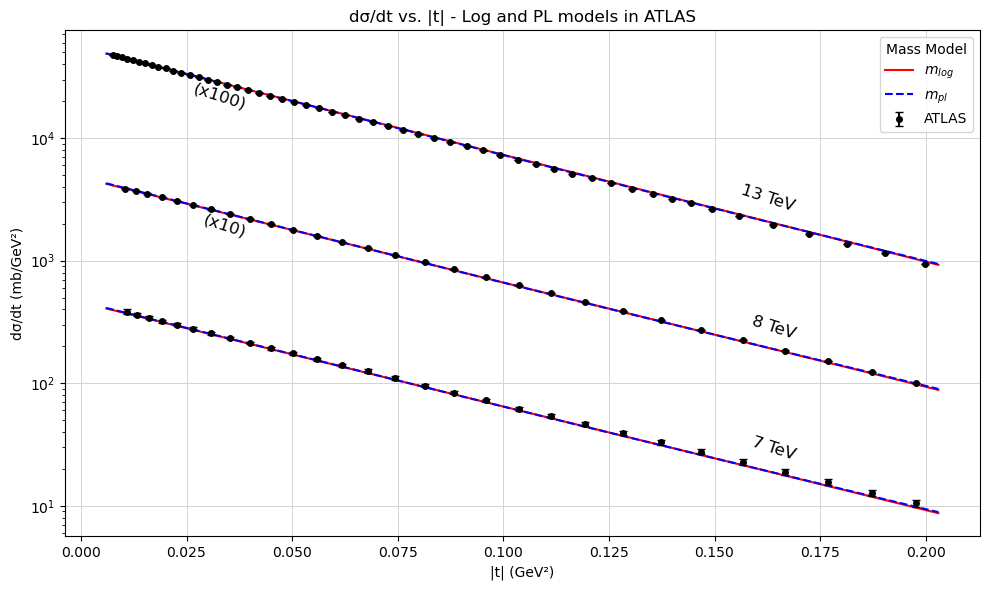

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# --- Funções equivalentes ---
def add_differential_trace(ax, x, y, color='red', mg_model='log', width=1.5, label=None):
    linestyle = '-' if mg_model == 'log' else '--'
    ax.plot(x, y, color=color, linewidth=width, linestyle=linestyle, label=label)


def add_data_trace(ax, x, y, y_error, scale=1.0, color='black', size=4,
                   name=None, show_label=True, mode='markers', symbol=None):
    if symbol is None:
        symbol = 'o'
    ax.errorbar(x, y * scale, yerr=y_error * scale, fmt=symbol,
                color=color, markersize=size, linestyle='None',
                label=name if show_label else None, capsize=3)


# --- Criação da figura ---
fig_atlas, ax = plt.subplots(figsize=(10, 6))

# --- Modelos log ---
# --- Modelos log ---
# Modelos log
# --- Modelos log ---
add_differential_trace(ax, dif_sigma_log_atlas_7_q2, dif_sigma_log_atlas_7_values, color='red', mg_model='log', label=r'${m_{log}}$')
add_differential_trace(ax, dif_sigma_log_atlas_8_q2, dif_sigma_log_atlas_8_values, color='red', mg_model='log')
add_differential_trace(ax, dif_sigma_log_atlas_13_q2, dif_sigma_log_atlas_13_values, color='red', mg_model='log')

# Modelos pl
add_differential_trace(ax, dif_sigma_pl_atlas_7_q2, dif_sigma_pl_atlas_7_values, color='blue', mg_model='pl', label=r'${m_{pl}}$')
add_differential_trace(ax, dif_sigma_pl_atlas_8_q2, dif_sigma_pl_atlas_8_values, color='blue', mg_model='pl')
add_differential_trace(ax, dif_sigma_pl_atlas_13_q2, dif_sigma_pl_atlas_13_values, color='blue', mg_model='pl')

# --- Dados experimentais ---
# --- Dados experimentais ---
add_data_trace(ax, x_7_atlas, y_7_atlas, yerr_7_atlas, name='ATLAS', show_label=True)
add_data_trace(ax, x_8_atlas, y_8_atlas * 10, yerr_8_atlas, name=None, show_label=False)
add_data_trace(ax, x_13_atlas, y_13_atlas * 100, yerr_13_atlas, name=None, show_label=False)

# --- Layout / estilo ---
ax.set_title('dσ/dt vs. |t| - Log and PL models in ATLAS')
ax.set_xlabel('|t| (GeV²)')
ax.set_ylabel('dσ/dt (mb/GeV²)')
ax.set_yscale('log')
ax.text(0.2, 0.9, '(x100)', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)

ax.text(0.2, 0.64, '(x10)', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)


ax.text(0.8, 0.7, '13 TeV', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)

ax.text(0.8, 0.44, '8 TeV', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)

ax.text(0.8, 0.2, '7 TeV', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)

ax.set_facecolor('white')
ax.grid(True, color='lightgray', linestyle='-', linewidth=0.7)
ax.legend(title='Mass Model')

plt.tight_layout()
plt.savefig("total_differential_cross_section_atlas_sic.pdf")
plt.show()




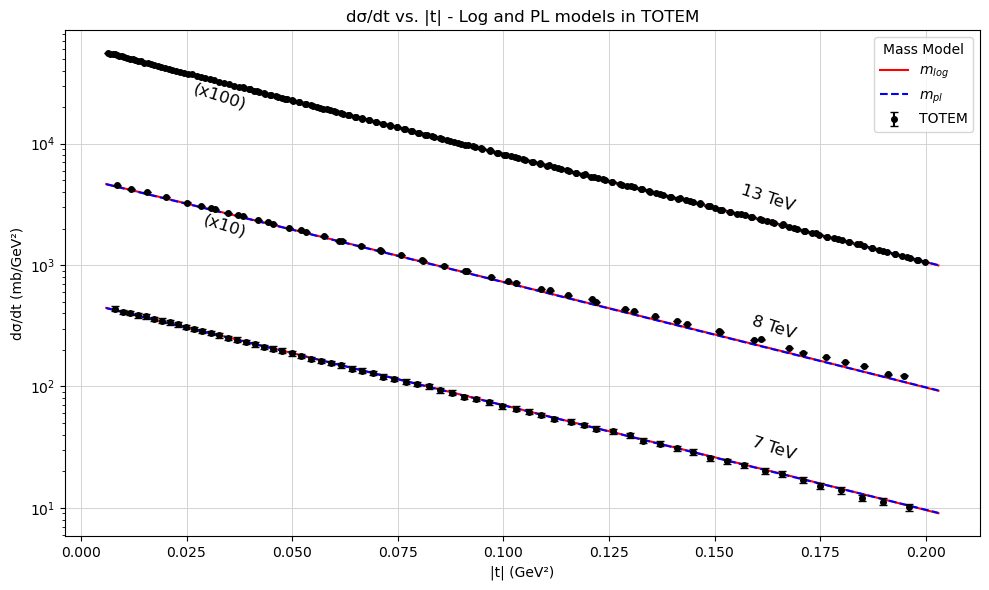

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# --- Funções equivalentes ---
def add_differential_trace(ax, x, y, color='red', mg_model='log', width=1.5, label=None):
    linestyle = '-' if mg_model == 'log' else '--'
    ax.plot(x, y, color=color, linewidth=width, linestyle=linestyle, label=label)


def add_data_trace(ax, x, y, y_error, scale=1.0, color='black', size=4,
                   name=None, show_label=True, mode='markers', symbol=None):
    if symbol is None:
        symbol = 'o'
    ax.errorbar(x, y * scale, yerr=y_error * scale, fmt=symbol,
                color=color, markersize=size, linestyle='None',
                label=name if show_label else None, capsize=3)

# --- Criação da figura ---
fig_totem, ax = plt.subplots(figsize=(10, 6))

# --- Modelos log ---
add_differential_trace(ax, dif_sigma_log_totem_7_q2, dif_sigma_log_totem_7_values, color='red', mg_model='log', label=r'${m_{log}}$')
add_differential_trace(ax, dif_sigma_log_totem_8_q2, dif_sigma_log_totem_8_values, color='red', mg_model='log')
add_differential_trace(ax, dif_sigma_log_totem_13_q2, dif_sigma_log_totem_13_values, color='red', mg_model='log')

# --- Modelos pl ---
add_differential_trace(ax, dif_sigma_pl_totem_7_q2, dif_sigma_pl_totem_7_values, color='blue', mg_model='pl', label=r'${m_{pl}}$')
add_differential_trace(ax, dif_sigma_pl_totem_8_q2, dif_sigma_pl_totem_8_values, color='blue', mg_model='pl')
add_differential_trace(ax, dif_sigma_pl_totem_13_q2, dif_sigma_pl_totem_13_values, color='blue', mg_model='pl')

# --- Dados experimentais ---
add_data_trace(ax, x_7_totem, y_7_totem, yerr_7_totem, name='TOTEM', show_label=True)
add_data_trace(ax, x_8_totem, y_8_totem * 10, yerr_8_totem, name= None, show_label=True)
add_data_trace(ax, x_13_totem, y_13_totem * 100, yerr_13_totem, name=None, show_label=True)

# --- Layout / estilo ---
ax.set_title('dσ/dt vs. |t| - Log and PL models in TOTEM')
ax.set_xlabel('|t| (GeV²)')
ax.set_ylabel('dσ/dt (mb/GeV²)')
ax.set_yscale('log')

ax.text(0.2, 0.9, '(x100)', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)

ax.text(0.2, 0.64, '(x10)', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)


ax.text(0.8, 0.7, '13 TeV', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)

ax.text(0.8, 0.44, '8 TeV', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)

ax.text(0.8, 0.2, '7 TeV', transform=ax.transAxes,
        fontsize=12, color='black', ha='right', va='top', rotation=-18)


ax.set_facecolor('white')
ax.grid(True, color='lightgray', linestyle='-', linewidth=0.7)
ax.legend(title='Mass Model')

plt.tight_layout()
plt.savefig("total_differential_cross_section_totem_sic.pdf")
plt.show()


In [17]:
data_sigma_tot_atlas = pd.read_csv(
    "../../../data/sigma_tot_2/ensemble_StRh_atlas.dat",
    delim_whitespace=True,
    header=None,
    nrows=70
)

data_sigma_tot_totem = pd.read_csv(
    "../../../data/sigma_tot_2/ensemble_StRh_totem.dat",  # Supondo que existe um arquivo similar para TOTEM
    delim_whitespace=True,
    header=None,
    nrows=80
)

x_sigma_tot_atlas = data_sigma_tot_atlas[0].to_numpy()
y_sigma_tot_atlas = data_sigma_tot_atlas[1].to_numpy()
y_error_sigma_tot_atlas = data_sigma_tot_atlas[2].to_numpy()

x_sigma_tot_totem = data_sigma_tot_totem[0].to_numpy()
y_sigma_tot_totem = data_sigma_tot_totem[1].to_numpy()
y_error_sigma_tot_totem = data_sigma_tot_totem[2].to_numpy()

start_sqrt_s = 1
max_sqrt_s = 13010
step = 100

def add_total_trace(fig, x, y, color='red', label='', line_style='solid', legend=True, size = 3, width = 2):
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines+markers',
        line=dict(color=color, width=width, dash=line_style),
        marker=dict(size=size),
        name = label, 
        showlegend=legend
    ))

def get_sigma_tot(epsilon, mg, a1, a2, mg_model):

    lst_sigma_tot = []
    lst_sqrt_s = []

    sqrt_s = start_sqrt_s

    while sqrt_s <= max_sqrt_s:
        def integrand(y, x, mg, a1, a2, m2_func):
            k = sqrt_s * x
            phi = 2 * np.pi * y
            jacobian = 2 * np.pi * sqrt_s

            return k * (T_1(k, 0.0, phi, mg, a1, a2, m2_func) - T_2(k, 0.0, phi, mg, a1, a2, m2_func)) * jacobian
        
        def amp_calculation(diff_T, s, epsilon):
            alpha_pomeron = 1.0 + epsilon
            regge_factor = (s / s0) ** alpha_pomeron
            
            return 1j * 8.0 * regge_factor * diff_T

        s = sqrt_s ** 2

        integral_value = fixed_quad(
            lambda x: fixed_quad(
                lambda y: integrand(y, x, mg, a1, a2, mg_model),
                0, 1, n=n_points)[0],

            0, 1, n=n_points)[0]
        
        lst_sigma_tot.append(sigma_tot(
            amp_calculation(integral_value, s, epsilon), s))
        
        lst_sqrt_s.append(sqrt_s)
        sqrt_s += step
    return lst_sigma_tot, lst_sqrt_s


/tmp/ipykernel_9569/2385249607.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sigma_tot_atlas = pd.read_csv(
/tmp/ipykernel_9569/2385249607.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sigma_tot_totem = pd.read_csv(


In [18]:
#-----------------------------------------------------------------------------------------------
sigma_tot_log_atlas_paper = get_sigma_tot(
    ensemble_parameters['atlas']['log']['epsilon'],
    ensemble_parameters['atlas']['log']['mg'],
    ensemble_parameters['atlas']['log']['a1'],
    ensemble_parameters['atlas']['log']['a2'],
    m2_log
)

sigma_tot_pl_atlas_paper = get_sigma_tot(
    ensemble_parameters['atlas']['pl']['epsilon'],
    ensemble_parameters['atlas']['pl']['mg'],
    ensemble_parameters['atlas']['pl']['a1'],
    ensemble_parameters['atlas']['pl']['a2'],
    m2_pl
)
sigma_tot_log_totem_paper = get_sigma_tot(
    ensemble_parameters['totem']['log']['epsilon'],
    ensemble_parameters['totem']['log']['mg'],
    ensemble_parameters['totem']['log']['a1'],
    ensemble_parameters['totem']['log']['a2'],
    m2_log
)

sigma_tot_pl_totem_paper = get_sigma_tot(
    ensemble_parameters['totem']['pl']['epsilon'],
    ensemble_parameters['totem']['pl']['mg'],
    ensemble_parameters['totem']['pl']['a1'],
    ensemble_parameters['totem']['pl']['a2'],
    m2_pl
)


lst_sqrt_s = sigma_tot_log_atlas_paper[1]

sigma_tot_log_atlas_values_paper = sigma_tot_log_atlas_paper[0]
sigma_tot_pl_atlas_values_paper = sigma_tot_pl_atlas_paper[0]
sigma_tot_log_totem_values_paper = sigma_tot_log_totem_paper[0]
sigma_tot_pl_totem_values_paper = sigma_tot_pl_totem_paper[0]

#-----------------------------------------------------------------------------------------------

sigma_tot_log_atlas = get_sigma_tot(
    m_log_atlas.values['eps'],
    m_log_atlas.values['mg'],
    m_log_atlas.values['a1'],
    m_log_atlas.values['a2'],
    m2_log
)

sigma_tot_pl_atlas = get_sigma_tot(
    m_pl_atlas.values['eps'],
    m_pl_atlas.values['mg'],
    m_pl_atlas.values['a1'],
    m_pl_atlas.values['a2'],
    m2_pl
)

sigma_tot_log_totem = get_sigma_tot(
    m_log_totem.values['eps'],
    m_log_totem.values['mg'],
    m_log_totem.values['a1'],
    m_log_totem.values['a2'],
    m2_log
)

sigma_tot_pl_totem = get_sigma_tot(
    m_pl_totem.values['eps'],
    m_pl_totem.values['mg'],
    m_pl_totem.values['a1'],
    m_pl_totem.values['a2'],
    m2_pl
)

lst_sqrt_s = sigma_tot_log_atlas[1]


sigma_tot_log_atlas_values = sigma_tot_log_atlas[0]
sigma_tot_pl_atlas_values = sigma_tot_pl_atlas[0]

sigma_tot_log_totem_values = sigma_tot_log_totem[0]
sigma_tot_pl_totem_values = sigma_tot_pl_totem[0]


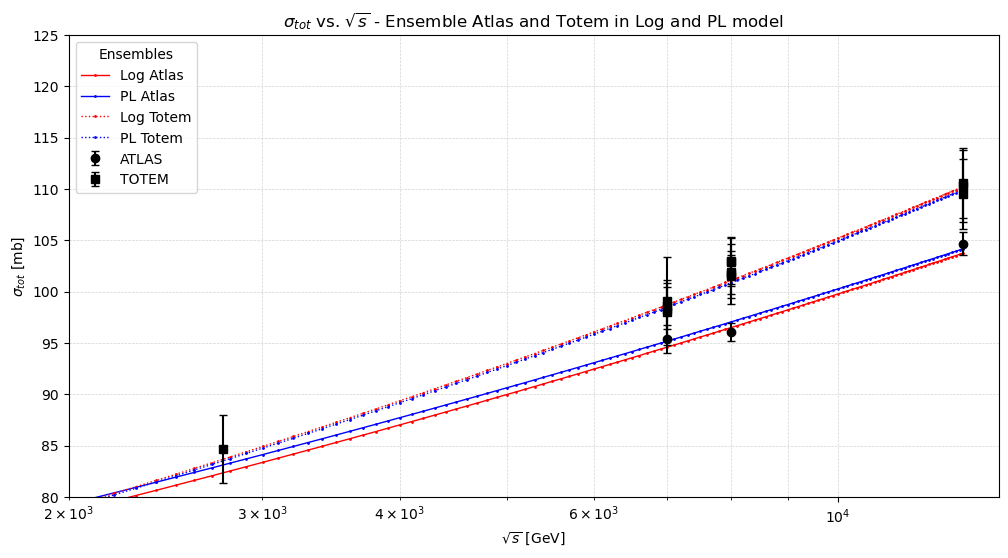

In [40]:
import matplotlib.pyplot as plt

def add_total_trace(ax, x, y, color='red', label='', line_style='solid', size=1, width=1):
    """
    Adiciona uma curva ao gráfico Matplotlib.

    ax: objeto matplotlib.axes.Axes
    x, y: dados
    color: cor da linha
    label: legenda
    line_style: 'solid', 'dotted', 'dashed', etc.
    size: tamanho do marcador
    width: largura da linha
    """
    ax.plot(
        x, y,
        color=color,
        linestyle=line_style,
        linewidth=width,
        marker='o',
        markersize=size,
        label=label
    )

# Criar figura e eixos
fig, ax = plt.subplots(figsize=(12, 6))

# Curvas principais
add_total_trace(ax, lst_sqrt_s, sigma_tot_log_atlas_values, color='red', label='Log Atlas', line_style='solid')
add_total_trace(ax, lst_sqrt_s, sigma_tot_pl_atlas_values, color='blue', label='PL Atlas', line_style='solid')

add_total_trace(ax, lst_sqrt_s, sigma_tot_log_totem_values, color='red', label='Log Totem', line_style='dotted')
add_total_trace(ax, lst_sqrt_s, sigma_tot_pl_totem_values, color='blue', label='PL Totem', line_style='dotted')


# Dados experimentais (com erro)
ax.errorbar(x_sigma_tot_atlas, y_sigma_tot_atlas, yerr=y_error_sigma_tot_atlas,
            fmt='o', color='black', label='ATLAS', capsize=3)
ax.errorbar(x_sigma_tot_totem, y_sigma_tot_totem, yerr=y_error_sigma_tot_totem,
            fmt='s', color='black', label='TOTEM', capsize=3)

# Configurações do gráfico
ax.set_title(r'$\sigma_{tot}$ vs. $\sqrt{s}$ - Ensemble Atlas and Totem in Log and PL model')
ax.set_xlabel(r'$\sqrt{s}$ [GeV]')
ax.set_ylabel(r'$\sigma_{tot}$ [mb]')
ax.set_xscale('log')
ax.set_xlim(2000, 14000)
ax.set_ylim(80, 125)
ax.grid(True, which='both', color='lightgray', linestyle='--', linewidth=0.5)
ax.legend(title='Ensembles')
plt.savefig("total_cross_section_sic.pdf")
plt.show()
